# ESM-Tools SimCat Examples

This notebook provides end-user examples of how the simulation catalog should work. If run on `albedo`, the experiment paths work.

A traditional workflow is shown below. The scientist would need to know the full paths to all of the experiments they might be interested in:

In [1]:
import pathlib
import xarray as xr
import pyfesom2 as pf2

EXPERIMENTS = {
"basic-001": pathlib.Path("/albedo/work/user/pgierz/SciComp/Tutorials/AWIESM_Basics/experiments/basic-001"), 
"basic-002": pathlib.Path("/albedo/work/user/pgierz/SciComp/Tutorials/AWIESM_Basics/experiments/basic-002"),
"branchoff-002": pathlib.Path("/albedo/work/user/pgierz/SciComp/Tutorials/AWIESM_Basics/experiments/branchoff-002"),
}

EXPERIMENTS

ERROR 1: PROJ: proj_create_from_database: Open of /albedo/soft/sw/conda-sw/analysis-toolbox/07.2024/share/proj failed
/albedo/soft/sw/conda-sw/analysis-toolbox/07.2024/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/albedo/soft/sw/conda-sw/analysis-toolbox/07.2024/lib/python3.9/site-packages/pyfesom2/climatology.py:14: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


{'basic-001': PosixPath('/albedo/work/user/pgierz/SciComp/Tutorials/AWIESM_Basics/experiments/basic-001'),
 'basic-002': PosixPath('/albedo/work/user/pgierz/SciComp/Tutorials/AWIESM_Basics/experiments/basic-002'),
 'branchoff-002': PosixPath('/albedo/work/user/pgierz/SciComp/Tutorials/AWIESM_Basics/experiments/branchoff-002')}

In [2]:
FESOM_DS = {expid: xr.open_mfdataset(f"{exp_path}/outdata/fesom/*nc") for expid, exp_path in EXPERIMENTS.items()}

FESOM is unstructured, so we need to also load the mesh. Again, this information needs you to know about the file paths. We get a little bit of help since it is encoded directly as an attribute of the NetCDF outdata:

In [3]:
FESOM_DS['basic-001'].FESOM_MeshPath

'/albedo/pool/FESOM2/core2/'

In [4]:
mesh = pf2.load_mesh(FESOM_DS['basic-001'].FESOM_MeshPath)

/albedo/pool/FESOM2/core2/pickle_mesh_py3_fesom2
The usepickle == True)
The pickle file for FESOM2 exists.
The mesh will be loaded from /albedo/pool/FESOM2/core2/pickle_mesh_py3_fesom2


For a very quick plot, we can just do a scatter plot (`lon`, `lat`, `data`). First lets meld together the mesh and the dataset:

In [5]:
FESOM_DS_WITH_MESH = {expid: ds.assign_coords(nod2=range(1, mesh.n2d+1), lat=("nod2", mesh.y2), lon=("nod2", mesh.x2)) for expid, ds in FESOM_DS.items()}

In [20]:
FESOM_DS_WITH_MESH['basic-001']["elem"] = (("nelem", "three"), mesh.elem)  # Store triangulation as a data variable

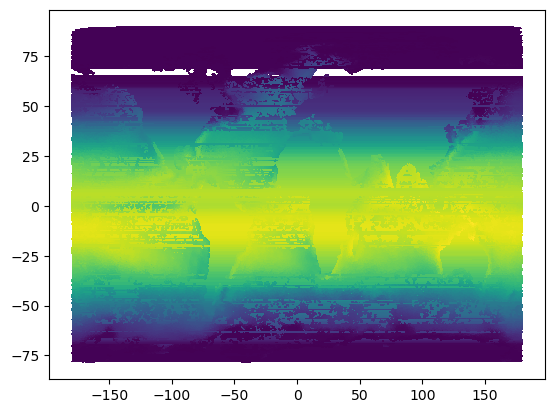

In [21]:
import matplotlib.pyplot as plt
ds = FESOM_DS_WITH_MESH['basic-001']
sst_mean = ds['sst'].mean(dim="time").compute()
fig, ax = plt.subplots()
ax.tripcolor(ds.lon.values, ds.lat.values, ds.elem.values, sst_mean.values)

Not particularly beautiful, but, the idea should be clear. Beautiful plots are a separate topic.

Now, we want to replace the loading of the data to instead come from a *STAC Catalog* so that we don't need to care about the paths of the data at all.